## 5.3 Gradient Descent

**실제값을 Y=4X+6 시뮬레이션하는 데이터 값 생성**

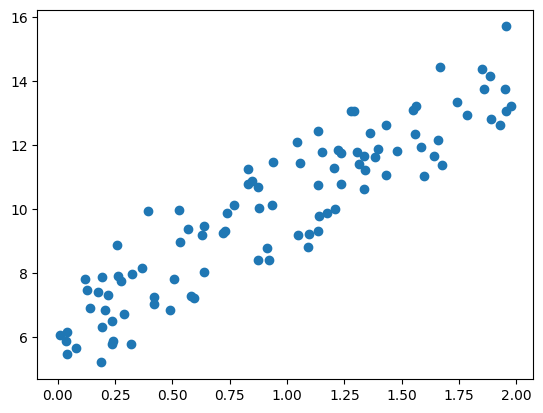

In [73]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 난수 고정
np.random.seed(0)

# y = 4X + 6 형태의 데이터를 생성
# X: 0~2 사이의 랜덤값 100개
# y: 6 + 4X + 노이즈
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)

# 생성한 데이터 시각화
plt.scatter(X, y)

In [74]:
# X와 y의 shape 확인
X.shape, y.shape

((100, 1), (100, 1))

**w0과 w1의 값을 최소화 할 수 있도록 업데이트 수행하는 함수 생성**

* 예측 배열 y_pred는 np.dot(X, w1.T) + w0 임
100개의 데이터 X(1,2,...,100)이 있다면 예측값은 w0 + X(1)*w1 + X(2)*w1 +..+ X(100)*w1이며, 이는 입력 배열 X와 w1 배열의 내적임.
* 새로운 w1과 w0를 update함
![](./image01.png)

In [75]:
# 현재 가중치(w1)와 절편(w0) 기준으로
# 경사하강법에서 사용할 업데이트 값을 계산하는 함수
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)

    # w1, w0와 같은 shape의 0 배열 생성
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)

    # 예측값 계산: y_pred = X*w1 + w0
    y_pred = np.dot(X, w1.T) + w0

    # 실제값 - 예측값 오차
    diff = y - y_pred

    # 절편(w0) 업데이트를 위한 1 벡터 생성
    w0_factors = np.ones((N, 1))

    # MSE 기준 gradient를 이용해 w1, w0 업데이트 값 계산
    w1_update = -(2 / N) * learning_rate * (np.dot(X.T, diff))
    w0_update = -(2 / N) * learning_rate * (np.dot(w0_factors.T, diff))

    return w1_update, w0_update

In [76]:
# 업데이트 값 계산 과정 shape 확인용 예제
w0 = np.zeros((1, 1))
w1 = np.zeros((1, 1))

# 초기 예측값
y_pred = np.dot(X, w1.T) + w0

# 오차 계산
diff = y - y_pred
print(diff.shape)

# 절편 업데이트용 1 벡터
w0_factors = np.ones((100, 1))

# 실제 업데이트 값 계산
w1_update = -(2 / 100) * 0.01 * (np.dot(X.T, diff))
w0_update = -(2 / 100) * 0.01 * (np.dot(w0_factors.T, diff))

print(w1_update.shape, w0_update.shape)
w1, w0

(100, 1)
(1, 1) (1, 1)


(array([[0.]]), array([[0.]]))

**반복적으로 경사 하강법을 이용하여 get_weigth_updates()를 호출하여 w1과 w0를 업데이트 하는 함수 생성**

In [77]:
# 전체 데이터를 사용하여 지정한 횟수만큼 경사하강법 수행
def gradient_descent_steps(X, y, iters=10000):
    # 초기 w0, w1은 0으로 설정
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    # 반복적으로 업데이트
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

**예측 오차 비용을 계산을 수행하는 함수 생성 및 경사 하강법 수행**

In [78]:
# 비용 함수(MSE) 계산
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

# 경사하강법 수행
w1, w0 = gradient_descent_steps(X, y, iters=1000)

# 최종 파라미터 출력
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0, 0], w0[0, 0]))

# 예측값 계산
y_pred = w1[0, 0] * X + w0

# 최종 비용 출력
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


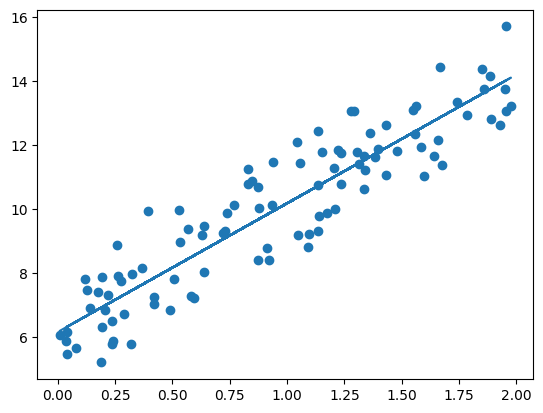

In [79]:
# 원본 데이터와 회귀선 시각화
plt.scatter(X, y)
plt.plot(X, y_pred)

**미니 배치 확률적 경사 하강법을 이용한 최적 비용함수 도출**

In [80]:
# 미니배치 확률적 경사하강법(SGD) 수행 함수
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    # 초기 w0, w1
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))
    prev_cost = 100000
    iter_index =0

    for ind in range(iters):
        np.random.seed(ind)

        # 전체 데이터의 인덱스를 랜덤하게 섞음
        stochastic_random_index = np.random.permutation(X.shape[0])

        # batch_size만큼 샘플 추출
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]

        # 샘플 데이터 기준으로 gradient 계산 및 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

In [81]:
# SGD 수행 및 결과 확인
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)

print("w1:", round(w1[0, 0], 3), "w0:", round(w0[0, 0], 3))


# 예측값 계산
y_pred = w1[0, 0] * X + w0

# 비용 출력
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


## 5.4 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측

Housing 데이터셋 크기 : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


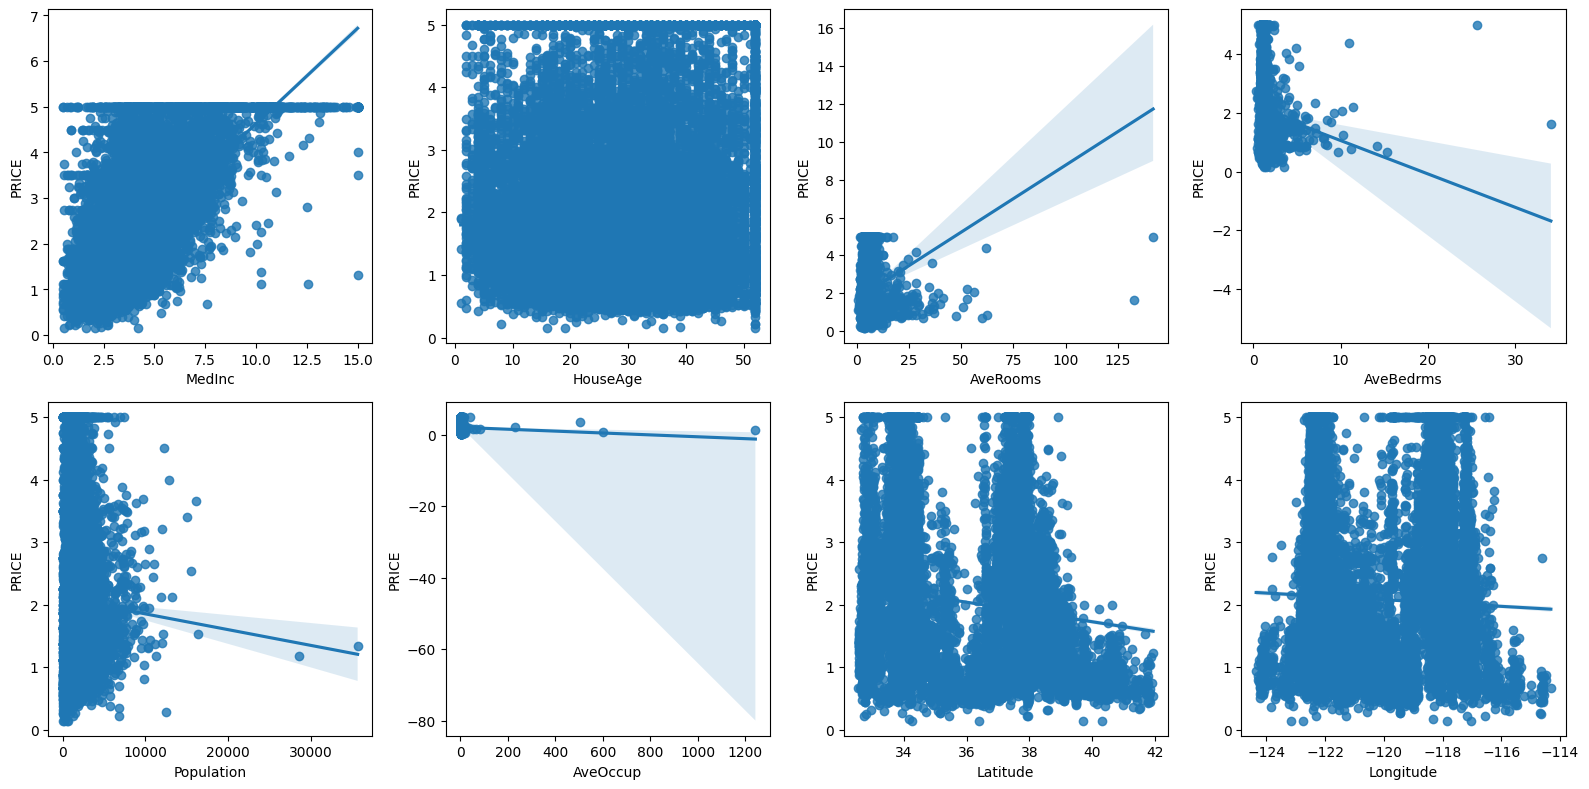

MSE : 0.543 , RMSE : 0.737
Variance score(R^2) : 0.595
절편 값: -37.239053052941664
회귀 계수값: [ 0.432  0.01  -0.099  0.598 -0.    -0.007 -0.425 -0.438]

회귀 계수 내림차순 정렬
AveBedrms     0.598
MedInc        0.432
HouseAge      0.010
Population   -0.000
AveOccup     -0.007
AveRooms     -0.099
Latitude     -0.425
Longitude    -0.438
dtype: float64

5 folds 의 개별 Negative MSE scores:  [-0.485 -0.622 -0.646 -0.543 -0.495]
5 folds 의 개별 RMSE scores :  [0.696 0.789 0.804 0.737 0.703]
5 folds 의 평균 RMSE : 0.746


In [64]:
# 기존 Boston housing 예제가 최신 sklearn 환경에서 동작하지 않아 California housing 데이터셋으로 대체하여 동일한 선형회귀 과정을 수행해야함
# 해당 셀은 생성형ai을 통해서 작성함


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 5.4 LinearRegression 예제
# 기존 load_boston() 대신 fetch_california_housing() 사용
# =========================

# 1. 데이터 로드
housing = fetch_california_housing()

# 2. DataFrame 생성
housingDF = pd.DataFrame(housing.data, columns=housing.feature_names)
housingDF['PRICE'] = housing.target

print('Housing 데이터셋 크기 :', housingDF.shape)
display(housingDF.head())

# 3. 주요 feature와 PRICE 관계 시각화
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)

lm_features = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'Latitude', 'Longitude'
]

for i, feature in enumerate(lm_features):
    row = i // 4
    col = i % 4
    sns.regplot(x=feature, y='PRICE', data=housingDF, ax=axs[row][col])

plt.tight_layout()
plt.show()

# 4. 학습/테스트 데이터 분리
y_target = housingDF['PRICE']
X_data = housingDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.3, random_state=156
)

# 5. 선형 회귀 학습/예측
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)

# 6. 평가
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3f}'.format(mse, rmse))
print('Variance score(R^2) : {0:.3f}'.format(r2_score(y_test, y_preds)))

# 7. 절편과 회귀 계수 출력
print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 3))

# 8. 회귀 계수 정렬 출력
coeff = pd.Series(data=np.round(lr.coef_, 3), index=X_data.columns)
print('\n회귀 계수 내림차순 정렬')
print(coeff.sort_values(ascending=False))

# 9. 5-Fold 교차검증
neg_mse_scores = cross_val_score(
    lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5
)

rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('\n5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print('5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 3))
print('5 folds 의 평균 RMSE : {0:.3f}'.format(avg_rmse))

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 무시
%matplotlib inline

# 보스턴 주택 가격 데이터 로드
boston = load_boston()

# DataFrame으로 변환
bostonDF = pd.DataFrame(boston.data, columns=boston.feature_names)

# 타깃값(주택 가격)을 PRICE 컬럼으로 추가
bostonDF['PRICE'] = boston.target

print('Boston 데이타셋 크기 :', bostonDF.shape)
bostonDF.head()

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

* CRIM: 지역별 범죄 발생률  
* ZN: 25,000평방피트를 초과하는 거주 지역의 비율
* NDUS: 비상업 지역 넓이 비율
* CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
* NOX: 일산화질소 농도
* RM: 거주할 수 있는 방 개수
* AGE: 1940년 이전에 건축된 소유 주택의 비율
* DIS: 5개 주요 고용센터까지의 가중 거리
* RAD: 고속도로 접근 용이도
* TAX: 10,000달러당 재산세율
* PTRATIO: 지역의 교사와 학생 수 비율
* B: 지역의 흑인 거주 비율
* LSTAT: 하위 계층의 비율
* MEDV: 본인 소유의 주택 가격(중앙값)

* 각 컬럼별로 주택가격에 미치는 영향도를 조사

In [ ]:
# 주요 feature와 PRICE 간의 관계를 산점도 + 회귀선으로 시각화
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)

# 시각화할 feature 목록
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']

for i, feature in enumerate(lm_features):
    row = int(i / 4)
    col = i % 4

    # regplot: 산점도 + 선형 회귀선
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

# 현재 figure 저장
fig1 = plt.gcf()
fig1.savefig('p322_boston.tif', format='tif', dpi=300, bbox_inches='tight')

**학습과 테스트 데이터 세트로 분리하고 학습/예측/평가 수행**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 타깃 데이터와 feature 데이터 분리
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

# 학습용 / 테스트용 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.3, random_state=156
)

# 선형 회귀 모델 생성 및 학습
lr = LinearRegression()
lr.fit(X_train, y_train)

# 예측 수행
y_preds = lr.predict(X_test)

# 평가 지표 계산
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3F}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

In [ ]:
# 절편과 회귀 계수 출력
print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

In [ ]:
# 회귀 계수를 Series로 만든 뒤 큰 값 순으로 정렬
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns)
coeff.sort_values(ascending=False)

In [ ]:
from sklearn.model_selection import cross_val_score

# 전체 데이터를 대상으로 5-fold 교차검증 수행
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

# scoring='neg_mean_squared_error'는 음수 MSE 반환
neg_mse_scores = cross_val_score(
    lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5
)

# RMSE로 변환
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

## 5-5. Polynomial Regression과 오버피팅/언더피팅 이해
### Polynomial Regression 이해

PolynomialFeatures 클래스로 다항식 변환

![](./image02.png)

In [66]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 2x2 입력 데이터 생성
X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 feature:\n', X)

# 2차 다항식 feature로 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)

print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


3차 다항식 결정값을 구하는 함수 polynomial_func(X) 생성. 즉 회귀식은 결정값 y = 1+ 2x_1 + 3x_1^2 + 4x_2^3

In [67]:
# 3차 다항식 형태의 target 값을 생성하는 함수
# y = 1 + 2x1 + 3x1^2 + 4x2^3
def polynomial_func(X):
    y = 1 + 2 * X[:, 0] + 3 * X[:, 0]**2 + 4 * X[:, 1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0, 4).reshape(2, 2)

print('일차 단항식 계수 feature: \n', X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


3차 다항식 계수의 피처값과 3차 다항식 결정값으로 학습

In [68]:
# 3차 다항식 feature 생성
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n', poly_ftr)

# 선형회귀 모델로 다항회귀 수행
model = LinearRegression()
model.fit(poly_ftr, y)

# 학습된 회귀 계수 출력
print('Polynomial 회귀 계수\n', np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


**사이킷런 파이프라인(Pipeline)을 이용하여 3차 다항회귀 학습**  

사이킷런의 Pipeline 객체는 Feature 엔지니어링 변환과 모델 학습/예측을 순차적으로 결합해줍니다.

In [69]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

# 동일한 다항식 target 생성 함수
def polynomial_func(X):
    y = 1 + 2 * X[:, 0] + 3 * X[:, 0]**2 + 4 * X[:, 1]**3
    return y

# Pipeline으로 다항식 변환 + 선형회귀를 한 번에 연결
model = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('linear', LinearRegression())
])

X = np.arange(4).reshape(2, 2)
y = polynomial_func(X)

# 학습 수행
model = model.fit(X, y)

# Pipeline 내부 선형회귀 모델의 계수 확인
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 다항 회귀를 이용한 과소적합 및 과적합 이해

**cosine 곡선에 약간의 Noise 변동값을 더하여 실제값 곡선을 만듬**

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 실제 함수: cosine 기반
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# 0~1 사이 랜덤값 30개 생성
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# 실제 함수값 + 노이즈
y = true_fun(X) + np.random.randn(n_samples) * 0.1

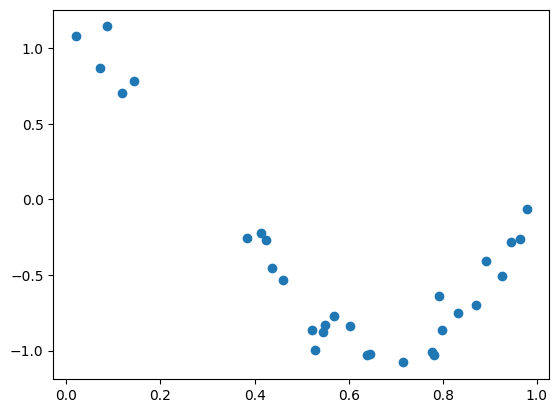

In [71]:
# 샘플 데이터 시각화
plt.scatter(X, y)


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.4077289625098685 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987232064 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899390e+05 -1.87416123e+06  2.03716219e+07
 -1.44873283e+08  7.09315363e+08 -2.47065792e+09  6.24561050e+09
 -1.15676510e+10  1.56894936e+10 -1.54006023e+10  1.06457264e+10
 -4.91377530e+09  1.35919645e+09 -1.70380786e+08] 입니다.
Degree 15 MSE 는 181238256.56423894 입니다.


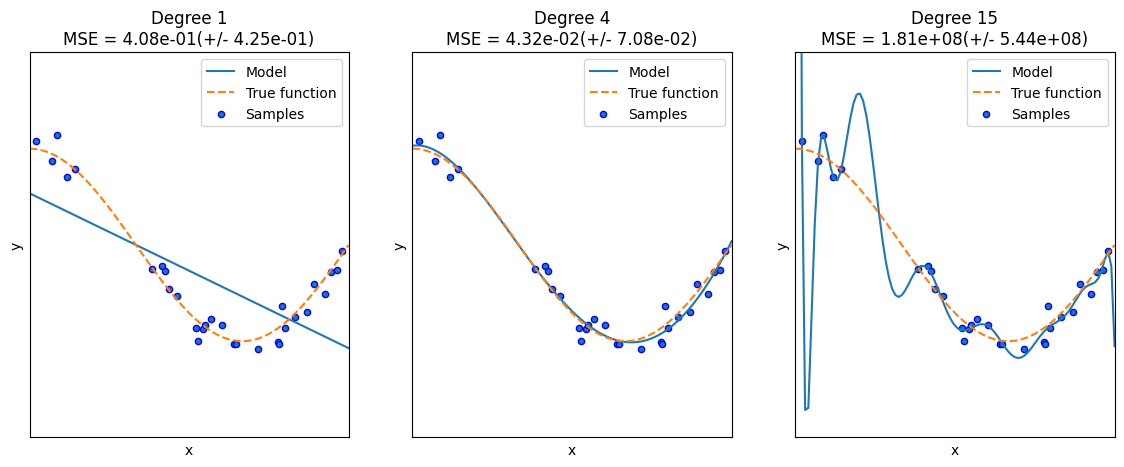

In [72]:
# degree를 바꿔가며 과소적합/적절한 적합/과적합 비교
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # 다항식 feature 변환 + 선형회귀 모델 생성
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()

    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression)
    ])

    # 학습
    pipeline.fit(X.reshape(-1, 1), y)

    # 10-fold 교차검증으로 성능 평가
    scores = cross_val_score(
        pipeline, X.reshape(-1, 1), y,
        scoring="neg_mean_squared_error", cv=10
    )

    # 회귀 계수 확인
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1 * np.mean(scores)))

    # 테스트용 x축 생성
    X_test = np.linspace(0, 1, 100)

    # 예측 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")

    # 실제 함수 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")

    # 원본 샘플
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))

plt.show()